*NLP @ HSE DSBA, autumn 2026. Author: Daria Andreeva*

# Seminar 6 — The Bill: How Models Could Afford to Grow

Last week one 124M decoder did everything, and we counted what an answer costs: one forward pass per token, and a cache so the prefix is not read twice. We also left two things unpaid — the cache's memory, and the question nobody asked out loud: if 124M was enough for a seminar, why is nothing you actually use that small?

GPT-2 at its largest was 1.5 billion parameters, trained on 40 GB of text, reading 1 024 tokens at a time. Five years later the same block — attention, feed-forward, a residual stream — runs at hundreds of billions of parameters, on trillions of tokens, over a hundred thousand tokens of context. Nobody invented a new architecture in between. What happened is that somebody worked out **what growing costs**, and then replaced, one by one, the parts of the block that sent the largest bills.

So today is a seminar about bills. There is no training in it (we simply cannot train almost anything on our own from now on, because we do not have that much of compute): every number is either something you compute by hand from a `config.json`, or one forward pass through a model somebody else trained.

And the question for today is basically

* **How did models afford to become a hundred times bigger than GPT-2?**

### The claim for today:

$$\underbrace{6\,N\,D}_{\text{training: paid once}} \qquad \underbrace{2\,N_{\text{active}}}_{\text{compute: paid per token}} \qquad \underbrace{\text{weights} \;+\; 2\,L\,h_{kv}\,d_{head}\cdot T}_{\text{memory: paid per request}}$$

Three bills. The block of 2017 still stands; what changed are the parts that sent these bills.

# Some dependencies

In [ ]:
# Colab setup. If needed, uncomment the following lines to install dependencies and clone the repository.
# The notebook reads weeks 1, 4 and 5 from ../, so clone the whole repo.
#!pip install -q "transformers>=5" datasets accelerate
#!git clone -q --branch autumn-2026 https://github.com/xufana/dsba_nlp.git
#%cd dsba_nlp/week06_modern_llm

In [1]:
import json
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import Dataset, load_dataset
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer

warnings.filterwarnings("ignore")
transformers.logging.set_verbosity_error()
transformers.logging.disable_progress_bar()               # no weight-loading bars

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

MODEL_OLD = "gpt2"                                # 124M, 2019 — last week's body
MODEL_NEW = "HuggingFaceTB/SmolLM2-135M"          # 135M, 2024 — the same budget, five years later
MODEL_CHAT = "HuggingFaceTB/SmolLM2-1.7B-Instruct"    # section 4: the same family, bigger, taught to take instructions
MODEL_DRAFT = "HuggingFaceTB/SmolLM2-135M-Instruct"   # section 4: the small one that drafts for it
PYTHIA_LIVE = ["70m", "160m", "410m"]             # three of one family's eight sizes, live; the artifact has six (all eight with --full)

W1, W4, W5 = "../week01_text_representations", "../week04_pretraining_transfer", "../week05_decoder_only"
ART_DIR = "artifacts"
RECOMPUTE = False                                 # True: rebuild every artifact with precompute.py (about an hour on an M-series Mac)

N_DEMO = 200                                      # texts behind every live measurement

/Users/andreeva.dal/personal/dsba_nlp/week06_modern_llm/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: mps


In [2]:
SEED = 42
CLASS_NAMES = ["World", "Sports", "Business", "Sci/Tech"]
CLASS_WORDS = [" world", " sports", " business", " technology"]       # week 5 §3.0: the verbalizer that won
SYSTEM_PROMPT = "You restore punctuation and capitalisation. Return the same words in the same order, and nothing else."


def n_params(module):
    return sum(p.numel() for p in module.parameters())


PEAK = 0.0


def gpu_gb():
    """What the GPU holds *right now*, in GB — reserved, cache included, so it is comparable to the device's total.
    Apple's backend has no peak counter, so PEAK is sampled here by whoever calls this."""
    global PEAK
    now = (torch.mps.driver_allocated_memory() / 1e9 if torch.backends.mps.is_available() else
           torch.cuda.memory_reserved() / 1e9 if torch.cuda.is_available() else 0.0)
    PEAK = max(PEAK, now)
    return now


def free():
    """Give the allocator's cache back. `del` the model first — this cannot reach the caller's names."""
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()

# 0. Where we stopped

## 0.1 The data, and the table we keep

AG News, the same test set, and week 5's two functions: `target_text` cleans the original, `strip_text` is what a speech recogniser would hand you. The results table comes back with three rows — TF-IDF from week 1, the fine-tuned encoder from week 4, last week's decoder as a zero-shot scorer — and today adds rows without training anything.

In [3]:
def target_text(text):
    """Week 5's clean-up: the original, minus AG News' line-break and entity artifacts ("\\", "#36;")
    and minus tokens that are punctuation only ("-", "&")."""
    text = text.replace("\\", " ").replace("#36;", "$")
    return " ".join(w for w in text.split() if re.search(r"[A-Za-z0-9]", w))


def strip_text(text):
    """What ASR hands you: lower case, no punctuation. Apostrophes stay — they are pronounced."""
    return re.sub(r"[^a-z0-9' ]", "", text.lower())

In [4]:
ds = load_dataset("fancyzhx/ag_news")
ag_test = ds["test"]
demo_texts = [target_text(t) for t in ag_test["text"][:N_DEMO]]
gold = np.array(ag_test["label"][:N_DEMO])

results = []


def record(model, test_acc, note=""):
    results.append({"model": model, "test acc": round(test_acc, 4), "note": note})


def show_results():
    return pd.DataFrame(results).set_index("model")


week1 = pd.read_csv(f"{W1}/artifacts/reference_results.csv")
tfidf = week1[week1.representation.str.startswith("tf-idf")].sort_values("accuracy").iloc[-1]
record("TF-IDF + logreg (week 1)", tfidf.accuracy, tfidf.representation)
w4_ft = json.load(open(f"{W4}/artifacts/agnews_transfer.json"))
record("fine-tuned BERT, everything (week 4)", w4_ft["runs"]["everything"]["accuracy"][-1], f"{w4_ft['n_train']:,} texts")
w5_zero = json.load(open(f"{W5}/artifacts/zero_shot_gpt2.json"))["results"]["one token each, sum"]
record("zero-shot scorer, GPT-2 (week 5)", w5_zero["accuracy"], "4 passes per text, no training")
show_results()

,test acc,note
model,,
TF-IDF + logreg (week 1),0.9195,"tf-idf, words 1-2"
"fine-tuned BERT, everything (week 4)",0.9108,"6,000 texts"
"zero-shot scorer, GPT-2 (week 5)",0.6059,"4 passes per text, no training"


## 0.2 The bill

Last week's cost table counted *passes per item* — what one answer costs, with the model taken as given. Today the model is not given. The table below is about the model itself: how many parameters $N$, how many tokens it read $D$, what the training cost, what the weights and the cache weigh, and how much of the model actually runs for one token. One row per model; every section adds a column.

**Bet, for the whole seminar:** you have GPT-2's 124M parameters and everything that has been learned since 2019. What do you change? Write down three things. We come back to the list in section 4.

In [5]:
bill = {}


def charge(model, **columns):
    bill.setdefault(model, {}).update(columns)


def human(x):
    # 1.75e11 -> "175B", 3.15e23 -> "3.15e+23", small numbers as they are
    if not isinstance(x, (int, float)) or pd.isna(x):
        return "" if not isinstance(x, str) else x
    for unit, size in [("T", 1e12), ("B", 1e9), ("M", 1e6)]:
        if size <= abs(x) < 1000 * size:
            return f"{x / size:.3g}{unit}"
    return f"{x:.2e}" if abs(x) >= 1e15 else f"{x:,.0f}" if abs(x) >= 100 else f"{x:.3g}"


def show_bill():
    return pd.DataFrame(bill).T.map(human)

# 1. The bill for training

First, what we're trying to calculate? A FLOP is one floating-point operation — one multiplication or one addition. A matrix product of an $m \times k$ matrix by a $k \times n$ one is $m \cdot n \cdot k$ multiply-adds, so $2mnk$ FLOPs, and a transformer is almost nothing but matrix products — the counts below are the sum of those. Mind the S: **FLOPs** is a count of operations, **FLOP/s** (often written FLOPS) is a rate — how many a chip does per second. The bill is in the first; the hardware is sold by the second.

**Why count them, rather than hours or dollars.** Hours depend on the chip, dollars on the year and the cloud, and neither is in a paper. The operation count is a property of the model and the data alone: it is the same on an A100 and on a laptop, and the paper gives the two numbers it is made of. Divide it by a chip's rate and you have time; multiply by the price of the chip-hour and you have money. One number that converts to both and lets a 2019 model and a 2024 one sit in the same column — that is what this section's bill is kept in.

And the conversion is not hard: an A100 is rated at $3.1 \times 10^{14}$ FLOP/s in bf16, and a real training run uses 30–50% of that. GPT-3's $3.15 \times 10^{23}$ FLOPs is then around $2.5 \times 10^{9}$ A100-seconds — eighty GPU-years, a thousand cards for a month.


## 1.1 Six N D

One formula carries this whole section. A forward pass costs about $2N$ floating-point operations per token — every weight is used in one multiplication and one addition. The backward pass costs about twice the forward. So training on $D$ tokens costs

$$C \;\approx\; 6\,N\,D \;\;\text{FLOPs}, \qquad \text{and generating one token} \;\approx\; 2\,N.$$

That is all (Kaplan et al. 2020). To be completely honest, the formula ignores what attention adds on top of the weights (a term that grows with the context), counts the embedding table as if it were multiplied, and forgets the optimiser — so it is good to tens of percent, not to the digit. For a bill whose rows differ by factors of a thousand, that is enough.

Let's try and calculate before running the cell:

1. GPT-3: $N = 175$ B parameters, $D = 300$ B tokens. $6ND$?
2. SmolLM2-135M: $N = 134.5$ M, $D = 2$ T tokens. $6ND$ — and how many times cheaper than GPT-3, for a model that read how many times *more*?
3. Tokens per parameter, $D/N$: GPT-3; Chinchilla (70B parameters, 1.4T tokens); Llama-3-8B (8B, 15T); SmolLM2-135M.

In [6]:
charge("GPT-2 small (2019)", N=124_439_808, D=40e9 / 4)      # WebText is 40 GB of text; 4 bytes per token is a guess — 4.1 measures it
charge("GPT-3 (2020)", N=175e9, D=300e9)
charge("Chinchilla (2022)", N=70e9, D=1.4e12)
charge("Llama-3-8B (2024)", N=8.03e9, D=15e12)
charge("SmolLM2-135M (2024)", N=134_515_008, D=2e12)
for row in bill.values():
    row["tokens / param"] = row["D"] / row["N"]
    row["train FLOPs"] = 6 * row["N"] * row["D"]
show_bill()

,N,D,tokens / param,train FLOPs
GPT-2 small (2019),124M,10B,80.4,7.47e+18
GPT-3 (2020),175B,300B,1.71,3.15e+23
Chinchilla (2022),70B,1.4T,20,5.88e+23
Llama-3-8B (2024),8.03B,15T,"1,868",7.23e+23
SmolLM2-135M (2024),135M,2T,"14,868",1.61e+21


So, the formula seems pretty accurate, and now you have the compute bill of the most expensive model of 2020 matching its article. Although, GPT-2's row is an estimate. OpenAI published the size of WebText in gigabytes, not in tokens, and not how many passes over it the training made. Treat that row as the order of magnitude.

SmolLM2-135M cost $1.6 \times 10^{21}$ — 195 times less than GPT-3 — while reading 6.7 times more text. $N$ and $D$ are two separate dials, and the last column but one says how differently people have set them: 1.7 tokens per parameter for GPT-3, 20 for Chinchilla, 1 900 for Llama-3-8B, 14 900 for SmolLM2.

Also, the small model is not the cheap one. Look at the last column again: Llama-3-8B — a model that runs on a laptop — took more compute to train than GPT-3. Nobody would have paid that for an 8B model in 2020. Hold on to that row too.



## 1.2 The law

Okay, by 2020 it became pretty obvious, that the more layers we have, the better is the model.


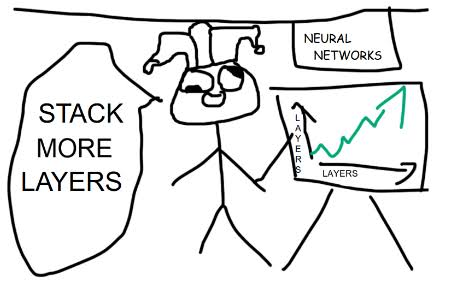

We clearly see, that GPT3 was significantly more expensive, so why would anyone pay $3 \times 10^{23}$ FLOPs for a language model in 2020 without knowing we're gonna be successful by doing so? Because by then it was known what the money buys. Kaplan et al. (2020) trained hundreds of transformers, from under a thousand parameters to over a billion, and found that the test loss is a **power law** in each of the three quantities, across the whole range, with nothing else — depth, width, number of heads — mattering much:

$$L(N) \propto N^{-0.076}, \qquad L(D) \propto D^{-0.095}, \qquad L(C) \propto C^{-0.050}$$

**What each law says.**

- $L(N) \propto N^{-0.076}$ — what a bigger model buys, *given enough data*. Without that condition the law does not hold: a large model on a small dataset is limited by the data.
- $L(D) \propto D^{-0.095}$ — what more data buys, *given a model large enough*. A small model is limited by its own size, however much it reads.
- $L(C) \propto C^{-0.050}$ — what money buys, *given that it is split well between $N$ and $D$*. The exponent is smaller than the other two because $C = 6ND$: the same money has to pay for both the parameters and the tokens.

That is a brutal law, and it is the best news the field ever had. Brutal: nine thousand times the model for half the loss. Good news: it is a *straight line on log-log paper*, so you can measure the slope on models you can afford and read off the loss of the model you cannot — **before** buying the cluster. A bet became an investment with a forecast. That, more than any architectural idea, is how models could afford to grow: somebody could show the curve to whoever was paying.

We can see the line ourselves without training anything. Last week we used `pythia-160m`. It has seven siblings: eight sizes, 70M to 12B, trained on the same corpus (the Pile, about 300B tokens) *in the same order*, with a checkpoint saved every thousand steps (Biderman et al. 2023). Same data, same recipe, only $N$ changes — a scaling experiment somebody already paid for.

Make a guess: draw the loss against the number of parameters on log-log axes, 70M to 2.8B. A straight line? Does it bend, and which way?

In [7]:
@torch.no_grad()
def bits_per_byte(model, tokenizer, texts, batch_size=16):
    """Next-token loss in bits per UTF-8 byte of text — the unit that survives a change of tokenizer.
    Every text starts from <bos>, so every byte of it is predicted by something."""
    start = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else tokenizer.eos_token_id
    nats = 0.0
    for i in range(0, len(texts), batch_size):
        seqs = [[start] + tokenizer(t, add_special_tokens=False).input_ids for t in texts[i:i + batch_size]]
        width = max(map(len, seqs))
        ids = torch.tensor([s + [start] * (width - len(s)) for s in seqs], device=model.device)
        mask = torch.tensor([[1] * len(s) + [0] * (width - len(s)) for s in seqs], device=model.device)
        logits = model(input_ids=ids, attention_mask=mask).logits[:, :-1].float()
        nats += (F.cross_entropy(logits.transpose(1, 2), ids[:, 1:], reduction="none") * mask[:, 1:]).sum().item()
    return nats / np.log(2) / sum(len(t.encode()) for t in texts)

In [8]:
rows = []
for size in PYTHIA_LIVE:
    name = f"EleutherAI/pythia-{size}"
    tok = AutoTokenizer.from_pretrained(name)
    model = AutoModelForCausalLM.from_pretrained(name).to(device).eval()
    rows.append({"model": f"pythia-{size}", "parameters": n_params(model),
                 "without embeddings": n_params(model) - n_params(model.get_input_embeddings()) - n_params(model.get_output_embeddings()),   # Pythia's two tables are separate
                 "bits / byte": bits_per_byte(model, tok, demo_texts)})
    del model
free()
live = pd.DataFrame(rows).set_index("model")
live

,parameters,without embeddings,bits / byte
model,,,
pythia-70m,70426624,18915328,1.516753
pythia-160m,162322944,85056000,1.321994
pythia-410m,405334016,302311424,1.136972


In [ ]:
if RECOMPUTE:
    !python precompute.py --only scaling

scaling = json.load(open(f"{ART_DIR}/scaling.json"))
by_size, by_step = pd.DataFrame(scaling["by_size"]), pd.DataFrame(scaling["by_step"])
slope_N = -np.polyfit(np.log(by_size.params_non_embedding), np.log(by_size.bits_per_byte), 1)[0]

fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.8))
ax[0].loglog(by_size.params_non_embedding, by_size.bits_per_byte, marker="o", label=f"{scaling['n_texts']:,} test texts ({scaling['device']}); slope −{slope_N:.3f}")
ax[0].loglog(live["without embeddings"], live["bits / byte"], "x", ms=9, color="k", label=f"live, {N_DEMO} texts")
for r in by_size.itertuples():
    ax[0].annotate(r.name.split("-")[1], (r.params_non_embedding, r.bits_per_byte), textcoords="offset points", xytext=(4, 5), fontsize=8)
ax[0].set(xlabel="N: parameters, embeddings not counted", ylabel="loss on AG News, bits per byte", title=f"{len(by_size)} sizes, one corpus, one data order")
ax[0].legend(fontsize=8)
ax[1].loglog(by_step.tokens_seen, by_step.bits_per_byte, marker="o", color="C1")
ax[1].set(xlabel="tokens seen so far", ylabel="loss on AG News, bits per byte", title="pythia-160m along its own training run")
plt.tight_layout()

<!-- REVISE AFTER PRECOMPUTE: the measured slope, where the line bends, the two ends of the right panel. -->

Read the left panel first. The sizes sit close to a line; the fitted slope is printed in the legend — put it next to Kaplan's 0.076 and do not expect the two to agree to the second digit. Their exponent was measured on the training distribution, with the irreducible part of the loss left in; ours is on news the models were not trained on, a sample of the test set, and the largest sizes saw the same 300B tokens as the smallest, so they are the least "trained to convergence" of the family. What transfers is the shape: every multiplication of $N$ by a constant takes the same *fraction* off the loss.

The right panel is the other dial, on one model: the same 160M parameters, looked at earlier and earlier in its training run. It is a learning curve, not Kaplan's $L(D)$ — that law is about models trained to the end on datasets of different sizes — but it says what the bill needs: the tokens are paid for in $6ND$, and each further doubling of them buys less.

Both panels slope down, so both dials are worth turning, and $6ND$ charges for their *product*. Which leaves the question the next section answers: with a fixed budget $C$, how much goes into $N$ and how much into $D$?



## 1.3 How to split the money

Hoffmann et al. (2022) ran the experiment properly: 400 models, sizes and data budgets varied independently, and for each compute budget they found the pair $(N, D)$ with the lowest loss. The answer is nearly a constant ratio — the optimum has **about 20 tokens per parameter**, and $N$ and $D$ should grow in step. Their demonstration was a model called Chinchilla: 70B parameters on 1.4T tokens, the same compute as the 280B-parameter Gopher on 300B tokens — a quarter of the size, and better on almost every benchmark. By that rule GPT-3, at 1.7 tokens per parameter, was a model far too big for the data it was given.

Let's calculate: You have GPT-3's compute, $3.15 \times 10^{23}$ FLOPs, and the rule $D = 20N$. What $N$ and $D$ do you train?

<details>
<summary>Answer</summary>

$6 \cdot N \cdot 20N = C \;\Rightarrow\; N = \sqrt{C/120} \approx 51$B parameters, $D \approx 1.0$T tokens. A model 3.4 times smaller than GPT-3, on 3.4 times the data.

</details>

Now look at the bill again: Llama-3-8B at 1 900 tokens per parameter, SmolLM2-135M at 14 900. Not 20. These models are *overtrained* by Chinchilla's rule, by two and three orders of magnitude, and the people who trained them knew the rule.

**Open question 1:** Chinchilla minimises one of the three bills in the claim. Which one? Now take a model that, over its lifetime, will *generate* many more tokens than it was trained on — or one that has to fit on a laptop. Which bills does its owner pay, and which of $N$ and $D$ appears in them? Why does that push $N$ down and $D$ up — and how many generated tokens does it take before serving has cost more than training?

# 2. What had to be replaced

The law says *grow*. This section is about what physically stood in the way — and it is easiest to see on two models with the same budget.

## 2.0 Two passports

`gpt2`, 2019, 124M parameters. `SmolLM2-135M`, 2024, 135M parameters. The same money, five years apart. Let's compare them:

In [9]:
old_tok, new_tok = AutoTokenizer.from_pretrained(MODEL_OLD), AutoTokenizer.from_pretrained(MODEL_NEW)
old = AutoModelForCausalLM.from_pretrained(MODEL_OLD).to(device).eval()
new = AutoModelForCausalLM.from_pretrained(MODEL_NEW).to(device).eval()
co, cn = old.config, new.config

pd.DataFrame({
    "GPT-2 small, 2019": {"layers": co.n_layer, "d_model": co.n_embd, "query heads": co.n_head, "key/value heads": co.n_head,
                          "FFN hidden": 4 * co.n_embd, "FFN": "up, GELU, down", "norm": "LayerNorm, before each sublayer", "positions": f"learned table, {co.n_positions:,} rows",
                          "context": co.n_positions, "vocabulary": co.vocab_size, "biases": "everywhere", "parameters": n_params(old)},
    "SmolLM2-135M, 2024": {"layers": cn.num_hidden_layers, "d_model": cn.hidden_size, "query heads": cn.num_attention_heads,
                           "key/value heads": cn.num_key_value_heads, "FFN hidden": cn.intermediate_size, "FFN": "up × SiLU(gate), down",
                           "norm": "RMSNorm, before each sublayer", "positions": f"rotation, θ = {cn.rope_parameters['rope_theta']:,.0f}",
                           "context": cn.max_position_embeddings, "vocabulary": cn.vocab_size, "biases": "none", "parameters": n_params(new)}})

,"GPT-2 small, 2019","SmolLM2-135M, 2024"
layers,12,30
d_model,768,576
query heads,12,9
key/value heads,12,3
FFN hidden,3072,1536
FFN,"up, GELU, down","up × SiLU(gate), down"
norm,"LayerNorm, before each sublayer","RMSNorm, before each sublayer"
positions,"learned table, 1,024 rows","rotation, θ = 100,000"
context,1024,8192
vocabulary,50257,49152


In [10]:
print(old.transformer.h[0], "\n")
print(new.model.layers[0])

GPT2Block(
  (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  (attn): GPT2Attention(
    (c_attn): Conv1D(nf=2304, nx=768)
    (c_proj): Conv1D(nf=768, nx=768)
    (attn_dropout): Dropout(p=0.1, inplace=False)
    (resid_dropout): Dropout(p=0.1, inplace=False)
  )
  (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  (mlp): GPT2MLP(
    (c_fc): Conv1D(nf=3072, nx=768)
    (c_proj): Conv1D(nf=768, nx=3072)
    (act): NewGELUActivation()
    (dropout): Dropout(p=0.1, inplace=False)
  )
) 

LlamaDecoderLayer(
  (self_attn): LlamaAttention(
    (q_proj): Linear(in_features=576, out_features=576, bias=False)
    (k_proj): Linear(in_features=576, out_features=192, bias=False)
    (v_proj): Linear(in_features=576, out_features=192, bias=False)
    (o_proj): Linear(in_features=576, out_features=576, bias=False)
  )
  (mlp): LlamaMLP(
    (gate_proj): Linear(in_features=576, out_features=1536, bias=False)
    (up_proj): Linear(in_features=576, ou

Read the two printouts against each other — the same four sublayers in both: two norms, an attention, a feed-forward. (PyTorch prints modules in the order they were *created*, so Llama's norms come last; they run first. And GPT-2's `c_attn` is queries, keys and values in one matrix, $768 \to 2\,304$.) Almost every line of the passport differs; four of the differences are sections below.

**Let's calculate:**

Rebuild both parameter counts from the passports. For GPT-2 one block is attention ($4d^2$: queries, keys, values, output) plus a feed-forward ($8d^2$: up to $4d$ and back), every matrix with a bias, plus two LayerNorms; add the token table, the position table, and a final LayerNorm. For SmolLM2 the attention is two full matrices (queries, output) and two a third as wide (keys, values); the feed-forward is *three* matrices $d \times 1536$; no biases; no position table.

In [11]:
def decoder_params(vocab, d, layers, heads, kv_heads, hidden, head_dim=None, tied=True):
    """Parameters of a Llama-style decoder, from six numbers of its config.json."""
    hd = head_dim or d // heads
    attention = 2 * d * heads * hd + 2 * d * kv_heads * hd       # q and o are full size; k and v are kv_heads wide
    block = attention + 3 * d * hidden + 2 * d                   # + the three matrices of SwiGLU + two RMSNorm gains
    return layers * block + vocab * d * (1 if tied else 2) + d   # + the embedding (and the head, if not tied) + the final norm


def kv_cache_bytes(layers, kv_heads, head_dim, tokens, bytes_per_value=2):
    """K and V, in every layer, for every K/V head, for every token in the context. fp16 unless told otherwise."""
    return 2 * layers * kv_heads * head_dim * tokens * bytes_per_value

In [12]:
d, L = co.n_embd, co.n_layer
block_old = (3 * d * d + 3 * d) + (d * d + d) + (4 * d * d + 4 * d) + (4 * d * d + d) + 2 * 2 * d     # q,k,v | output | up | down | two LayerNorms — all with biases
by_hand_old = L * block_old + co.vocab_size * d + co.n_positions * d + 2 * d                       # + token table + position table + final LayerNorm
by_hand_new = decoder_params(cn.vocab_size, cn.hidden_size, cn.num_hidden_layers, cn.num_attention_heads, cn.num_key_value_heads, cn.intermediate_size)
print(f"GPT-2:   by hand {by_hand_old:>12,}   the checkpoint {n_params(old):>12,}")
print(f"SmolLM2: by hand {by_hand_new:>12,}   the checkpoint {n_params(new):>12,}")

pd.DataFrame({"GPT-2": {"attention, in d²": 4.0, "feed-forward, in d²": 8.0, "positions, parameters": co.n_positions * d},
              "SmolLM2": {"attention, in d²": 2 + 2 * cn.num_key_value_heads / cn.num_attention_heads,
                          "feed-forward, in d²": 3 * cn.intermediate_size / cn.hidden_size, "positions, parameters": 0}}).round(2)

GPT-2:   by hand  124,439,808   the checkpoint  124,439,808
SmolLM2: by hand  134,515,008   the checkpoint  134,515,008


,GPT-2,SmolLM2
"attention, in d²",4.0,2.67
"feed-forward, in d²",8.0,8.00
"positions, parameters",786432.0,0.00


124 439 808 and 134 515 008, to the last parameter. Nothing is hidden in a transformer: a dozen numbers in a JSON file, and arithmetic.

And the arithmetic already tells the story:

* **Depth instead of width.** 12 × 768 became 30 × 576. The same budget went into two and a half times as many layers.
* **The feed-forward is still $8d^2$** — with three matrices instead of two. Somebody was careful to keep that number (2.2).
* **The attention went from $4d^2$ to $2.67d^2$.** Keys and values are three times narrower (2.4), and what that saves is not mainly parameters.
* **Positions are no longer parameters.** 786 432 of them in GPT-2; zero here (2.3).

One thing in the passport is the same in both, and it is worth saying out loud because it is usually listed among the "modern" changes: *where* the norm stands — before each sublayer. **Which of today's list did GPT-2 already have?** — keep the question for 2.1.

## 2.1 The norm: where it stands, and what it computes

A norm is applied to one vector at a time — the $d$ numbers of one token at one layer, nothing across the batch or the sequence. Its job is to hand the next sublayer an input of a fixed scale, whatever the residual stream has grown to by layer 20: attention and the feed-forward are then trained against inputs of the same size at every depth. The transformer of 2017 and GPT-2 use **LayerNorm** (Ba et al. 2016): centre the vector, divide by its standard deviation, then let two learned $d$-vectors undo as much of that as training wants —

$$\text{LN}(x) = \frac{x - \mu}{\sigma} \odot \gamma + \beta, \qquad \mu = \tfrac1d \sum_i x_i,\quad \sigma = \sqrt{\tfrac1d \sum_i (x_i - \mu)^2}.$$

**RMSNorm** (Zhang & Sennrich 2019) keeps only the division. No mean is subtracted; the vector is divided by its root mean square, and a single gain remains —

$$\text{RMSNorm}(x) = \frac{x}{\text{RMS}(x)} \odot \gamma, \qquad \text{RMS}(x) = \sqrt{\tfrac1d \sum_i x_i^2 + \varepsilon}.$$

The $\varepsilon$ (SmolLM2: $10^{-5}$) only keeps a zero vector from dividing by zero. Every Llama-family model since 2023 uses this one; the eight-line class below is the whole of it.


In [13]:
class RMSNorm(nn.Module):
    """Divide by the root mean square, multiply by a learned gain. No mean subtracted, no bias added."""
    def __init__(self, d, eps=1e-5):
        super().__init__()
        self.weight, self.eps = nn.Parameter(torch.ones(d)), eps

    def forward(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight

In [ ]:
x = torch.tensor([3.0, -1.0, 2.0, 0.0])
print("LayerNorm:", F.layer_norm(x, (4,), eps=0).numpy().round(2))
print("RMSNorm:  ", RMSNorm(4, eps=0)(x).detach().numpy().round(2))
print(f"GPT-2:   {sum('.ln_' in n and n.endswith('weight') for n, _ in old.named_parameters())} LayerNorms, "
      f"{sum(p.numel() for n, p in old.named_parameters() if '.ln_' in n):,} parameters")
print(f"SmolLM2: {sum('norm' in n for n, _ in new.named_parameters())} RMSNorms,  "
      f"{sum(p.numel() for n, p in new.named_parameters() if 'norm' in n):,} parameters")

LayerNorm: [ 1.26 -1.26  0.63 -0.63]
RMSNorm:   [ 1.6  -0.53  1.07  0.  ]
GPT-2:   25 LayerNorms, 38,400 parameters
SmolLM2: 61 RMSNorms,  35,136 parameters


: 

$[1.26, -1.26, 0.63, -0.63]$ against $[1.60, -0.53, 1.07, 0]$. What RMSNorm dropped: the centring and the bias. A zero stays a zero; before the learned gain, the *direction* of the vector is untouched and only its length is fixed. Zhang & Sennrich's argument was that the re-scaling is what stabilises training and the re-centring is along for the ride — and it is a little less arithmetic per vector.

The parameter line is there to kill a misconception: 38 400 against 35 136. Nobody switched norms to save parameters, and the time saved in a transformer is a few percent at best. It is the habit that matters: at scale every operation that does not earn its place goes — the centring here, and the biases everywhere else in the block.

What matters more than which norm is **where it stands**, and that answers the question from 2.0. In the 2017 transformer and in BERT the norm comes *after* the residual addition — post-norm: every layer normalises the stream itself. From GPT-2 on, it stands *before* each sublayer — pre-norm: `x + attention(norm(x))`. The residual stream is never normalised, only read through a norm; it is a clean sum of everything the layers wrote (week 3 §5.2, and the logit lens of week 5 §1.2 depends on it). Gradients reach layer 1 of 30 through plain additions. Post-norm transformers need a careful warm-up to train at all (Xiong et al. 2020); pre-norm ones are routinely trained a hundred layers deep. Depth instead of width — the first line of the passport — was only affordable because of that. **Pre-norm is the one item on today's list that GPT-2 already had.**

## 2.2 The feed-forward: a gate, and the 8/3

The feed-forward of 2017 is two matrices and a nonlinearity: up to $4d$, ReLU or GELU, down. SwiGLU (Shazeer 2020, *GLU Variants Improve Transformer*) splits the way up in two parallel projections: one is the value, the other, through SiLU, is a **gate** that multiplies it —

$$\text{FFN}(x) = W_{down}\big(\,\text{SiLU}(W_{gate}\,x) \;\odot\; W_{up}\,x\,\big)$$

— so each hidden unit is a product of two linear views of the input, not a threshold on one. Three matrices instead of two.

GPT-2 spends $8d^2$ on a feed-forward. What hidden size $h$ gives a three-matrix feed-forward the same budget? Check it against SmolLM2: $d = 576$, hidden 1 536.

In [1]:
class SwiGLU(nn.Module):
    """Two parallel projections up — one is the value, the other, through SiLU, is its gate — and one projection down."""
    def __init__(self, d, hidden):
        super().__init__()
        self.gate_proj, self.up_proj = nn.Linear(d, hidden, bias=False), nn.Linear(d, hidden, bias=False)
        self.down_proj = nn.Linear(hidden, d, bias=False)

    def forward(self, x):
        return self.down_proj(F.silu(self.gate_proj(x)) * self.up_proj(x))

NameError: name 'nn' is not defined

In [ ]:
print(f"hidden / d = {cn.intermediate_size / cn.hidden_size:.3f};   3 · d · hidden = {3 * cn.intermediate_size / cn.hidden_size:.2f} d²")

z = torch.linspace(-5, 5, 200)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.3))
ax[0].plot(z, F.relu(z), label="ReLU, 2017"); ax[0].plot(z, F.gelu(z), label="GELU: BERT, GPT-2"); ax[0].plot(z, F.silu(z), label="SiLU = z · sigmoid(z)")
ax[0].set(xlabel="z", title="one input: a threshold", ylim=(-1, 5)); ax[0].legend(fontsize=8)
for value in [-1.0, 0.5, 1.0, 2.0]:
    ax[1].plot(z, F.silu(z) * value, label=f"value = {value}")
ax[1].set(xlabel="gate, before SiLU", title="SwiGLU: SiLU(gate) × value — two inputs per hidden unit"); ax[1].legend(fontsize=8)
plt.tight_layout()

$3 \cdot d \cdot h = 8d^2$ gives $h = \tfrac83 d$, and $576 \cdot \tfrac83 = 1\,536$ exactly. The "8/3" you meet in every Llama-style config is not a discovery about language; it is bookkeeping, so that a paper can say *same parameters, lower loss*. Llama-3-8B uses $14\,336 / 4\,096 = 3.5$ — the convention is a budget, not a law.

The left panel is what changed least: SiLU and GELU are nearly the same curve. The right panel is what changed: the output of a hidden unit depends on *two* projections of the input, and the gate can switch the value off, pass it, or — because SiLU dips below zero — flip its sign a little. Shazeer's own conclusion in the paper is a sentence worth quoting to anyone who asks why it works: he offers no explanation and attributes the result, as with everything else in the architecture, to divine benevolence. It trains to a lower loss at the same budget; that is the evidence. ModernBERT and Gemma use the same thing with GELU in the gate (GeGLU).

## 2.3 Positions: the rotation, on a real checkpoint

Week 5 §1.4 was the whole story of RoPE: the table that stops at row 1 024, the rotation that depends only on the offset, the ladder of frequencies, what happens past the training window. We did the arithmetic there on random vectors. Two things are left for today: see it on a checkpoint, and read one more number off the passport.

The function below is week 5's `rotate` for a whole tensor of heads — with the pairing Hugging Face uses, which that section warned about: coordinate $j$ turns with coordinate $j + d/2$, not $2i$ with $2i+1$.

**Bet:** tell SmolLM2 that the text does not start at position 0 but at position 1 000 — every token's position shifted by the same amount. Tell GPT-2 the same with a shift of 400. What happens to the logits of each?

In [ ]:
def rope(x, theta, first=0):
    """Rotate [B, heads, T, head_dim] by position, positions first, first + 1, …
    Hugging Face's pairing: coordinate j turns with coordinate j + head_dim / 2 (week 5 §1.4 paired 2i with 2i + 1)."""
    T, hd = x.shape[-2:]
    angle = torch.arange(first, first + T, device=x.device)[:, None] * theta ** (-torch.arange(0, hd, 2, device=x.device) / hd)
    cos, sin = angle.cos().repeat(1, 2), angle.sin().repeat(1, 2)                  # [T, head_dim]
    x1, x2 = x.chunk(2, dim=-1)
    return x * cos + torch.cat([-x2, x1], -1) * sin

In [ ]:
enc = new_tok(demo_texts[0], return_tensors="pt").to(device)
old_enc = old_tok(demo_texts[0], return_tensors="pt").to(device)
pos_new = torch.arange(enc.input_ids.shape[1], device=device)[None]
pos_old = torch.arange(old_enc.input_ids.shape[1], device=device)[None]
with torch.no_grad():
    here, far = new(**enc, position_ids=pos_new).logits, new(**enc, position_ids=pos_new + 1000).logits
    old_here, old_far = old(**old_enc, position_ids=pos_old).logits, old(**old_enc, position_ids=pos_old + 400).logits
print(f"SmolLM2, every position + 1 000: the largest change in any logit is {(here - far).abs().max():.1e} (logits reach {here.abs().max():.0f});  "
      f"next-token guess changed at {(here.argmax(-1) != far.argmax(-1)).float().mean():.0%} of positions")
print(f"GPT-2,   every position +   400: the largest change in any logit is {(old_here - old_far).abs().max():.1f};  "
      f"next-token guess changed at {(old_here.argmax(-1) != old_far.argmax(-1)).float().mean():.0%} of positions")

<!-- CHECK LIVE: SmolLM2's difference should be float noise against the size of the logits (expect 1e-4 … 1e-2 against logits of order 10, and no changed guess); GPT-2's share of changed guesses. -->

For SmolLM2 the difference is rounding error — three or more orders of magnitude below the logits themselves: 135M trained parameters, thirty layers, and not one of them can tell position 5 from position 1 005 — only how far apart two tokens are. For GPT-2 the shifted text is a different input: other rows of the table were added to it.

Now the passport line: `rope_theta`. Week 5's ladder was $\theta_i = 10\,000^{-2i/d}$; SmolLM2 has $100\,000$ there. Its predecessor, SmolLM (v1), had $10\,000$ and a context of 2 048 in its config; v2 has $100\,000$ and 8 192.

**By hand:**

9. A head has 32 coordinate pairs; pair $i$ completes a turn every $2\pi\,\theta^{\,2i/64}$ positions. Call a pair *slow* if it does not complete one turn inside the context. How many slow pairs at ($\theta = 10^4$, 2 048)? At ($10^4$, 8 192)? At ($10^5$, 8 192)?

In [ ]:
wavelength = lambda theta: 2 * np.pi * theta ** (np.arange(0, 64, 2) / 64)        # positions per full turn, pair by pair
for theta, window in [(1e4, 2048), (1e4, 8192), (1e5, 8192)]:
    print(f"theta = {theta:>9,.0f}, context {window:>5,}: {(wavelength(theta) > window).sum():>2} of 32 pairs never complete a turn;  "
          f"the slowest turns once in {wavelength(theta)[-1]:>9,.0f} positions")

11, then 7, then 12. The slow pairs are the ones that tell *near* from *far* without ambiguity — a pair that has gone round the circle more than once cannot. Quadruple the context with the old $\theta$ and four of the eleven are lost; raise $\theta$ tenfold and they are back. So $\theta$ is tuned to the context the way a ruler is chosen for the thing measured, and it is one of the two numbers to look at when a release note says "longer context". The other one is in 3.1, and it is in gigabytes.

## 2.4 Attention: fewer keys and values

One line of the passport is left: nine query heads, three key/value heads. This is **grouped-query attention** (Ainslie et al. 2023), and the class below is all of it — standard multi-head attention with the key and value projections a third as wide, and each K/V head *shared* by three query heads.

Why keys and values and not queries? Hold the question until 3.1; the comment on the line with `k = ...` is the hint.

In [ ]:
class Attention(nn.Module):
    """Causal self-attention with grouped queries: `heads` query heads read from `kv_heads` key/value heads."""
    def __init__(self, d, heads, kv_heads, theta):
        super().__init__()
        self.heads, self.kv_heads, self.theta, hd = heads, kv_heads, theta, d // heads
        self.q_proj, self.o_proj = nn.Linear(d, heads * hd, bias=False), nn.Linear(heads * hd, d, bias=False)
        self.k_proj, self.v_proj = nn.Linear(d, kv_heads * hd, bias=False), nn.Linear(d, kv_heads * hd, bias=False)

    def forward(self, x):
        B, T, _ = x.shape
        q = self.q_proj(x).view(B, T, self.heads, -1).transpose(1, 2)              # [B, heads, T, hd]
        k = self.k_proj(x).view(B, T, self.kv_heads, -1).transpose(1, 2)           # [B, kv_heads, T, hd] — what the cache keeps
        v = self.v_proj(x).view(B, T, self.kv_heads, -1).transpose(1, 2)
        q, k = rope(q, self.theta), rope(k, self.theta)                            # positions enter here, in every layer, and nowhere else
        share = self.heads // self.kv_heads                                        # each K/V head serves `share` query heads
        out = F.scaled_dot_product_attention(q, k.repeat_interleave(share, 1), v.repeat_interleave(share, 1), is_causal=True)
        return self.o_proj(out.transpose(1, 2).reshape(B, T, -1))

In [ ]:
heads, kv_heads = cn.num_attention_heads, cn.num_key_value_heads
gqa, mha = Attention(cn.hidden_size, heads, kv_heads, 1e5), Attention(cn.hidden_size, heads, heads, 1e5)
print(f"{heads} query heads on {kv_heads} K/V heads: {n_params(gqa):,} parameters;   on {heads} K/V heads: {n_params(mha):,}")
print("query head -> the K/V head it reads:", dict(zip(range(heads), torch.arange(kv_heads).repeat_interleave(heads // kv_heads).tolist())))

Each query head still asks its own question — nine different $q$ — but heads 0, 1, 2 look the answers up in the same keys and read the same values. The two ends of the dial have names: `kv_heads = heads` is the multi-head attention of 2017; `kv_heads = 1` is multi-*query* attention (Shazeer 2019), which Gemma 2B used. Everything in between is "grouped", and almost every model since 2023 sits there, usually at a quarter or a third.

A third fewer parameters in the attention is a small saving. The real one is in 3.1.

## 2.5 The block, assembled: sixty lines, their weights

We now have every part: `RMSNorm`, `SwiGLU`, `rope`, `Attention`. Two more classes put them in order, and the names of the attributes are chosen to match Hugging Face's, for one reason: so that the next cell can take the **trained weights of SmolLM2-135M and load them into our classes**. If our sixty lines are the model, the logits come out the same.

**Bet:** do they?

In [ ]:
class Block(nn.Module):
    def __init__(self, d, heads, kv_heads, hidden, theta, eps):
        super().__init__()
        self.input_layernorm, self.self_attn = RMSNorm(d, eps), Attention(d, heads, kv_heads, theta)
        self.post_attention_layernorm, self.mlp = RMSNorm(d, eps), SwiGLU(d, hidden)

    def forward(self, x):
        x = x + self.self_attn(self.input_layernorm(x))              # pre-norm: the residual stream itself is never normalised
        return x + self.mlp(self.post_attention_layernorm(x))


class Decoder(nn.Module):
    """A 2024 decoder. The attribute names are Hugging Face's Llama names, so a checkpoint's weights load as they are."""
    def __init__(self, vocab, d, layers, heads, kv_heads, hidden, theta, eps):
        super().__init__()
        self.embed_tokens = nn.Embedding(vocab, d)
        self.layers = nn.ModuleList(Block(d, heads, kv_heads, hidden, theta, eps) for _ in range(layers))
        self.norm = RMSNorm(d, eps)

    def forward(self, ids):
        x = self.embed_tokens(ids)
        for layer in self.layers:
            x = layer(x)
        return self.norm(x) @ self.embed_tokens.weight.T             # the head is the embedding, transposed (week 3 §4.5)

In [ ]:
mine = Decoder(cn.vocab_size, cn.hidden_size, cn.num_hidden_layers, cn.num_attention_heads, cn.num_key_value_heads, cn.intermediate_size,
               cn.rope_parameters["rope_theta"], cn.rms_norm_eps).to(device).eval()
mine.load_state_dict({k.removeprefix("model."): v for k, v in new.state_dict().items() if k != "lm_head.weight"})   # the head is tied: one tensor, two names
with torch.no_grad():
    theirs, ours = new(**enc).logits, mine(enc.input_ids)
print(f"{n_params(mine):,} parameters;  largest difference in any logit: {(theirs - ours).abs().max():.1e}  (the logits themselves reach {theirs.abs().max():.0f})")
print("prefix:       ", new_tok.decode(enc.input_ids[0, :8]))
print("next, theirs: ", repr(new_tok.decode(theirs[0, 7].argmax())), "  next, ours:", repr(new_tok.decode(ours[0, 7].argmax())))

<!-- CHECK LIVE: the difference should be float noise against logits of order 10. -->

The same numbers, to rounding. There is nothing else in there: no trick in the library, no hidden layer. A model that people call a "small LLM" is the six definitions above, a table of 49 152 vectors, and thirty copies of one block.

It is also the point to look back at week 3. That transformer had sinusoids added at the input, LayerNorm, a ReLU feed-forward, an encoder and cross-attention. Take away the encoder (week 5), move the norm in front (GPT-2), swap four parts (today) — and you have this. Seven years of architecture is a short diff. The long diff is in $N$, $D$ and $T$, and in the next section's bills.

# 3. The bill for serving

Training is paid once. A served model pays two bills on every request, and week 5 left both open: the **memory** the cache takes, and the **time** a token takes. This section prices them, and then looks at two things that are usually left out of the price: where the arithmetic physically happens, and what to do when the model no longer fits the compute you can spend per token.

## 3.1 Memory: the cache, with numbers

Week 5 §2.1: the model keeps $K$ and $V$ of every past token in every layer, so that a new token costs one row instead of a re-read of the prefix. What it keeps is exactly the tensor on the commented line of `Attention`: `[B, kv_heads, T, head_dim]`, twice, per layer. So the cache holds

$$2 \cdot L \cdot h_{kv} \cdot d_{head} \quad \text{numbers per token of context.}$$

**By hand:**

10. Numbers per token: GPT-2 (12 layers, 12 heads of 64). SmolLM2-135M (30 layers, 3 K/V heads of 64). SmolLM2 if it had kept 9 K/V heads.
11. Llama-3-8B: 32 layers, 8 K/V heads of 128, numbers stored in 16 bits. Kilobytes per token? Gigabytes at its context of 8 192? At 131 072 — the "128k" that Llama 3.1 put on the same shapes three months later? And without grouping, with all 32 heads?
12. A GPU with 24 GiB, Llama-3-8B in 16 bits (8.03B parameters). How many users can it hold at once at 8 192 tokens of context each?

(GiB is $2^{30}$ bytes — what a "24 GB" card actually has. The tables below use it throughout.)

In [ ]:
with torch.no_grad():
    cache_old, cache_new = old(**old_enc, use_cache=True).past_key_values, new(**enc, use_cache=True).past_key_values
print("GPT-2,   K of one layer:", tuple(cache_old.layers[0].keys.shape), "   [batch, heads, tokens, head_dim]")
print("SmolLM2, K of one layer:", tuple(cache_new.layers[0].keys.shape), "   — three heads, not nine")
measured = sum(l.keys.numel() + l.values.numel() for l in cache_new.layers) * cache_new.layers[0].keys.element_size()
T = enc.input_ids.shape[1]
print(f"SmolLM2, {T} tokens: {measured:,} bytes held; the formula at 4 bytes per number: "
      f"{kv_cache_bytes(cn.num_hidden_layers, cn.num_key_value_heads, cn.hidden_size // cn.num_attention_heads, T, 4):,}")

shapes = {"GPT-2 small": (12, 12, 64), "SmolLM2-135M": (30, 3, 64), "SmolLM2-135M, ungrouped": (30, 9, 64),
          "Llama-3-8B": (32, 8, 128), "Llama-3-8B, ungrouped": (32, 32, 128)}
pd.DataFrame({name: {"numbers / token": 2 * L * kv * hd, "KB / token, fp16": kv_cache_bytes(L, kv, hd, 1) / 1024,
                     "GiB at 8 192": kv_cache_bytes(L, kv, hd, 8192) / 2 ** 30, "GiB at 131 072": kv_cache_bytes(L, kv, hd, 131072) / 2 ** 30}
              for name, (L, kv, hd) in shapes.items()}).T.round(3)

In [ ]:
for name, row in bill.items():
    row["weights, GiB fp16"] = row["N"] * 2 / 2 ** 30
charge("GPT-2 small (2019)", **{"cache, KB / token": kv_cache_bytes(12, 12, 64, 1) / 1024})
charge("SmolLM2-135M (2024)", **{"cache, KB / token": kv_cache_bytes(30, 3, 64, 1) / 1024})
charge("Llama-3-8B (2024)", **{"cache, KB / token": kv_cache_bytes(32, 8, 128, 1) / 1024})
show_bill()

Read the first table by rows.

**SmolLM2 has two and a half times GPT-2's layers and a smaller cache** — 11 520 numbers per token against 18 432. Ungrouped it would be 34 560. That is the answer to 2.4's question: grouping the keys and values saves a third of the attention's *parameters* and two thirds of the *cache*, and the cache is the bill that grows with every token of every user. The queries are not cached — a query is used once, at its own step, and thrown away — so there was never a reason to group them.

**Llama-3-8B: 128 KB per token.** 1 GiB at 8 192 tokens. At the 131 072 of Llama 3.1 — the same shapes — 16 GiB, and the weights themselves, in 16 bits, are 15 GiB. At full context *the conversation weighs more than the model*. Without grouping it would be 64 GiB, for one user. This is the second number behind every "128k context" on a model card, next to $\theta$: the position scheme makes the long context *representable*, the K/V grouping makes it *storable*.

**Nine users.** Question 12: 24 GiB minus 15 GiB of weights leaves 9; at 1 GiB of cache per user that is nine conversations at once, whatever the card could compute. On a GPU that serves a language model the cache, not the weights and not the arithmetic, is the first thing to cap how many requests share it. That was the sentence week 5 owed you.

## 3.2 Time: prefill and decode

Week 5 §2: one pass over a 64-token prompt, or 64 passes to write 64 tokens. With the cache those are two different *regimes*, and a served model lives in both on every request:

* **prefill** — the prompt goes through in one pass, all positions in parallel, and leaves the cache behind. Its cost is the time to the first token.
* **decode** — one token per pass, each pass reading the whole cache. Its cost is the time *between* tokens.

`greedy` below is last week's loop with the cache written out — nothing hidden in `generate` — and `measure_serving` runs it at several prompt lengths.

**Bet:** in tokens per second, how much faster is prefill than decode at a prompt of 256 tokens? And does a decode step get slower as the prompt grows from 16 to 960?

In [ ]:
def sync(device):
    """A GPU call returns when the work is *queued*, not when it is done. This waits for the queue to drain."""
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


def ms(fn, device, repeat=10):
    """Median wall time of fn() in milliseconds: one warm-up call, the queue drained before and after every run."""
    fn()
    sync(device)
    times = []
    for _ in range(repeat):
        t = time.perf_counter()
        fn()
        sync(device)
        times.append(time.perf_counter() - t)
    return float(np.median(times)) * 1000

In [ ]:
@torch.no_grad()
def greedy(model, ids, n_new, round_trip=False):
    """Greedy decoding with the cache, written out: one prefill pass over the prompt, then one pass per new token.
    round_trip=True takes the argmax on the CPU, the way a careless loop does: a row of logits the size of the
    vocabulary crosses to the CPU and one token id crosses back, at every step."""
    out = model(ids, use_cache=True)
    new = []
    for _ in range(n_new):
        logits = out.logits[:, -1]
        if round_trip:
            token = torch.tensor([[int(np.argmax(logits.float().cpu().numpy()))]], device=ids.device)
        else:
            token = logits.argmax(-1, keepdim=True)
        new.append(token)
        out = model(token, past_key_values=out.past_key_values, use_cache=True)
    return torch.cat(new, 1), out.past_key_values


def measure_serving(model, tok, device, texts, lengths, n_new=32):
    """Prefill against decode at several prompt lengths, and the cache they leave behind."""
    stream = torch.tensor([tok(" ".join(texts)).input_ids[:max(lengths)]], device=device)
    rows = []
    for P in lengths:
        ids = stream[:, :P]
        with torch.no_grad():
            prefill = ms(lambda: model(ids, use_cache=True), device, repeat=5)
            total = ms(lambda: greedy(model, ids, n_new), device, repeat=3)
            cache = model(ids, use_cache=True).past_key_values
        layer = cache.layers[0].keys
        rows.append({"prompt tokens": P, "prefill, ms": round(prefill, 2), "prefill, tokens/s": round(P / prefill * 1000),
                     "decode, ms/token": round((total - prefill) / n_new, 2), "decode, tokens/s": round(n_new / (total - prefill) * 1000, 1),
                     "cache shape, one layer": list(layer.shape),
                     "cache, KB": round(sum(l.keys.numel() + l.values.numel() for l in cache.layers) * layer.element_size() / 1024, 1)})
    return rows

In [ ]:
texts = demo_texts * 5                                    # enough tokens for the longest prompt
pd.concat({"GPT-2 small": pd.DataFrame(measure_serving(old, old_tok, device, texts, [16, 64, 256, 960])),
           "SmolLM2-135M": pd.DataFrame(measure_serving(new, new_tok, device, texts, [16, 64, 256, 960]))}).set_index("prompt tokens", append=True).droplevel(1)

<!-- REVISE AFTER PRECOMPUTE: the measured ratio at 256, and whether decode ms/token moves with the prompt length on this machine. -->

Read the two `tokens/s` columns. Prefill pushes hundreds of tokens through the stack in one batched pass and the GPU does them in parallel; decode pushes *one*, and pays the full price of walking thirty layers for it — launching every kernel, reading every weight — to produce a single row. That is why the two rates are so far apart on the same model, and why providers price input and output tokens differently. The cache columns grow linearly with the prompt, by the formula of 3.1, to the byte.

Two numbers a user feels come straight from this table: **time to first token** is the prefill; **tokens per second** after that is the decode. A long system prompt costs the first and is nearly free in the second — and if a thousand users share the same system prompt, its cache can be computed once and shared: *prefix caching*, which answers the "what does the prefix cost per text" exercise of week 5.

<!-- LINK: the LLM-systems course page on prefill and the KV cache. -->

## 3.3 Where the arithmetic happens

Every notebook of this course has had the line `.to(device)` in it, and we have never said what it does. It **copies**. A model on a GPU lives in the GPU's memory; a Python list of token ids lives in the CPU's. One request crosses between them at least twice:

```
text ──tokenizer (CPU)──> ids ──copy──> GPU: embed, 30 blocks, unembed, argmax ──copy──> one id ──tokenizer (CPU)──> text
```

Three things about that picture cost time and are in no FLOP count.

**The GPU does not do what you say when you say it.** A line like `b = a @ a` on a GPU tensor *queues* the multiplication and returns. Python moves on; the work happens later. The moment you need a value on the CPU — `.item()`, `.cpu()`, `print(b)` — Python stops and waits for the whole queue. So a naive timer measures the wrong thing, and `sync` above exists to make ours honest.

**Bet:** a 4 096 × 4 096 matrix product on the GPU. How long does the Python line take to return — against how long the product takes to exist?

In [ ]:
a = torch.randn(4096, 4096, device=device)
a @ a; sync(device)                                       # warm-up: the first call also pays for loading the kernel
t = time.perf_counter()
b = a @ a
returned = time.perf_counter() - t
sync(device)
print(f"the line returned after {returned * 1000:.2f} ms;  the product existed after {(time.perf_counter() - t) * 1000:.2f} ms   ({device})")

<!-- REVISE AFTER PRECOMPUTE: on a GPU the first number is tens of microseconds and the second is milliseconds; on a CPU they are the same. -->

On a GPU the two numbers differ by orders of magnitude; on a CPU they are the same number, because there is no queue. Every timing in week 5 that ended in `generate` was honest by accident — `generate` hands back token ids, and that forces the wait. A timing of a bare forward pass is not.

**The copy costs by the byte, and a small tensor is cheaper to compute where it already is.** Two tables: the same vector on both sides and the price of carrying it across; and a matrix product at growing sizes, on the CPU, on the GPU, and on the GPU *with the round trip* — the matrix sent there and the result brought back.

**Bet:** from which size does the GPU win — and does the answer change when you count the trip?

In [ ]:
def measure_transfer(device, sizes=(1_000, 100_000, 10_000_000)):
    """The same vector on both sides, and what it costs to carry it across."""
    rows = []
    for n in sizes:
        x = torch.randn(n)
        g = x.to(device)
        rows.append({"floats": n, "MB": n * 4 / 1e6, "CPU -> GPU, ms": round(ms(lambda: x.to(device), device), 3),
                     "GPU -> CPU, ms": round(ms(lambda: g.cpu(), device), 3),
                     "x * 2 on CPU, ms": round(ms(lambda: x * 2, device), 3), "x * 2 on GPU, ms": round(ms(lambda: g * 2, device), 3)})
    return rows


def measure_matmul(device, sizes=(16, 64, 256, 1024, 2048)):
    """An n × n product where the data is, where the GPU is, and on the GPU with the trip there and back."""
    rows = []
    for n in sizes:
        x = torch.randn(n, n)
        g = x.to(device)
        rows.append({"n": n, "x @ x on CPU, ms": round(ms(lambda: x @ x, device), 3), "on GPU, ms": round(ms(lambda: g @ g, device), 3),
                     "on GPU, there and back, ms": round(ms(lambda: (x.to(device) @ x.to(device)).cpu(), device), 3)})
    return rows

In [ ]:
display(pd.DataFrame(measure_transfer(device)).set_index("floats"))
pd.DataFrame(measure_matmul(device)).set_index("n")

<!-- REVISE AFTER PRECOMPUTE: the crossover size on the class GPU, and the per-MB cost of the copy in each direction. -->

Read the second table across. At the small sizes the CPU wins outright: a GPU operation has a fixed cost of launching — tens of microseconds whatever the size — and a 16 × 16 product is over before the launch is. This is week 5's remark about the cached decode step, *"what it pays for is launching kernels, not arithmetic"*, measured on its own. At the large sizes the GPU wins by a wide margin, and the round trip takes some of it back. The first table says how much a megabyte costs to carry; a batch of token ids is kilobytes, a batch of logits is not — `[64, 262, 50 257]` floats is the 3.4 GB tensor that week 5's `score` was rewritten to avoid creating, and copying it to the CPU would have cost more than computing it.

On an M-series Mac there is no bus to cross — the CPU and the GPU share one memory — but there is still a copy into memory the GPU manages, and still the wait. The next cell puts the same tables from the machine that ran `precompute.py` under yours.

**The loop decides how often you pay.** A generation loop has to choose a token at every step. The choice can be made on the GPU — `argmax` there, and the id never leaves — or the careless way: bring the logits to the CPU, choose with numpy, send the id back. Same tokens, same model.

**Bet:** 64 tokens with SmolLM2. How much slower is the round trip — a few percent, or a few times?

In [ ]:
ids = torch.tensor([new_tok(" ".join(demo_texts[:4])).input_ids[:64]], device=device)
on_gpu = ms(lambda: greedy(new, ids, 64), device, repeat=3)
round_trip = ms(lambda: greedy(new, ids, 64, round_trip=True), device, repeat=3)
same = (greedy(new, ids, 64)[0] == greedy(new, ids, 64, round_trip=True)[0]).all().item()
print(f"64 tokens, argmax on the GPU: {on_gpu:.0f} ms;  argmax on the CPU, every step: {round_trip:.0f} ms  ({round_trip / on_gpu:.2f}x);  same tokens: {same}")
print(f"tokenizing one text on the CPU: {ms(lambda: new_tok(demo_texts[0]), device):.3f} ms;  "
      f"its ids to the GPU: {ms(lambda: torch.tensor(new_tok(demo_texts[0]).input_ids).to(device), device):.3f} ms")

if RECOMPUTE:
    !python precompute.py --only serving

serving = json.load(open(f"{ART_DIR}/serving.json"))
print(f"\nthe same measurements from precompute.py, on {serving['device']}:  a {serving['launch']['n']} × {serving['launch']['n']} product "
      f"returned after {serving['launch']['returned, ms']} ms and existed after {serving['launch']['existed, ms']} ms")
display(pd.DataFrame(serving["transfer"]).set_index("floats"))
display(pd.DataFrame(serving["matmul"]).set_index("n"))
pd.DataFrame({name: {k: v for k, v in r.items() if k != "by_length"} for name, r in serving["models"].items()}).T

<!-- REVISE AFTER PRECOMPUTE: the round-trip ratio here and on the M4; which of the two machines pays more per copy. -->

Whatever the ratio is on your machine, read what it is made of: a row of 49 152 logits is 200 KB — cheap to carry — and what the round trip really adds is a forced wait and two small copies at every step, 64 times. A loop that also *prints* each token as it goes, logs a tensor, or checks a stopping condition in Python pays the same toll. None of it is in $2N$ per token.

Three rules that come out of this section, and they hold for every model:

1. **Keep the loop on one side.** Choose, stop and count on the GPU; cross once, at the end.
2. **Time with a sync, or do not time.** Otherwise the cost shows up at whichever line first asks for a number.
3. **Small work belongs where the data already is.** A GPU is for tensors big enough to pay for the launch.

## 3.4 More parameters than you can afford to run

The compute bill is $2N$ per token, and the law of section 1 says the loss falls with $N$. So far those were the same $N$. A **mixture of experts** pulls them apart.

Look at where the parameters of a block are: the feed-forward is $8d^2$ of $10.67d^2$ — three quarters of every block. MoE keeps the attention as it is and replaces the feed-forward by $E$ feed-forwards of the same size and a tiny *router* — one linear layer that scores the $E$ experts for each token. The token goes through its top $k$ only, and their outputs are mixed with the router's softmax over those $k$. The model *owns* $E$ feed-forwards per block and *runs* $k$.

**By hand:**

13. A router scores four experts for one token: $[2, 1, 0, -1]$. Top-2. With what weights are the two outputs mixed?
14. Mistral 7B: 32 layers, $d = 4\,096$, feed-forward hidden 14 336 — 7.24B parameters. Mixtral 8x7B is the same model with 8 experts per block, 2 active. How many parameters does it have, and how many run for one token?
15. The other way round. gpt-oss-20b: 20.9B parameters, 3.6B active, 32 experts per block, 4 active. *Assume* active means the shared part plus four experts — how big is the shared part, and one expert (summed over the blocks)?

In [ ]:
class MoE(nn.Module):
    """`n_experts` feed-forwards and a router. Every token goes through its `top_k` best experts,
    mixed by the router's softmax over those k. Returns the output and which experts each token used."""
    def __init__(self, d, hidden, n_experts, top_k):
        super().__init__()
        self.router, self.top_k = nn.Linear(d, n_experts, bias=False), top_k
        self.experts = nn.ModuleList(SwiGLU(d, hidden) for _ in range(n_experts))

    def forward(self, x):
        weights, chosen = self.router(x).topk(self.top_k, dim=-1)                   # both [B, T, top_k]
        weights = weights.softmax(-1)
        out = torch.zeros_like(x)
        for e, expert in enumerate(self.experts):
            share = (weights * (chosen == e)).sum(-1)                               # [B, T]: this expert's weight for every token, 0 if not chosen
            rows = share > 0
            out[rows] += expert(x[rows]) * share[rows][:, None]                     # only the tokens that chose it pay for it
        return out, chosen

In [ ]:
torch.manual_seed(SEED)
moe = MoE(cn.hidden_size, cn.intermediate_size, n_experts=8, top_k=2).to(device)
with torch.no_grad():
    h = new(**enc, output_hidden_states=True).hidden_states[cn.num_hidden_layers // 2]       # real residual vectors, one per token
    out, chosen = moe(h)
active = n_params(moe.router) + 2 * n_params(moe.experts[0])
print(f"one MoE layer in place of SmolLM2's feed-forward: {n_params(moe):,} parameters owned, {active:,} run per token ({active / n_params(moe):.0%})")
print("token ->  its two experts")
for token, experts in list(zip(new_tok.convert_ids_to_tokens(enc.input_ids[0]), chosen[0].tolist()))[:8]:
    print(f"  {token:>12}  {experts}")
pd.Series(chosen.flatten().bincount(minlength=8).cpu().numpy(), name="tokens routed to expert").to_frame().T

In [ ]:
print("13. weights of the top two:", torch.tensor([2.0, 1.0]).softmax(0).numpy().round(2))

mistral = decoder_params(vocab=32000, d=4096, layers=32, heads=32, kv_heads=8, hidden=14336, tied=False)
ffn = 3 * 4096 * 14336 * 32                               # every feed-forward of the model
print(f"14. Mistral 7B: {mistral / 1e9:.2f}B, of which feed-forward {ffn / 1e9:.2f}B and everything else {(mistral - ffn) / 1e9:.2f}B")
print(f"    Mixtral 8x7B: owned {(mistral - ffn + 8 * ffn) / 1e9:.1f}B, run per token {(mistral - ffn + 2 * ffn) / 1e9:.1f}B")

total, active, E, k = 20.9, 3.6, 32, 4                    # assuming: total = shared + E · expert;  active = shared + k · expert
expert = (total - active) / (E - k)
print(f"15. gpt-oss-20b: one expert {expert:.2f}B, shared {total - E * expert:.2f}B")

for row in bill.values():
    row.setdefault("active N", row["N"])                  # a dense model runs all of itself
charge("Mixtral 8x7B (2023)", N=46.7e9, **{"active N": 12.9e9, "weights, GiB fp16": 46.7e9 * 2 / 2 ** 30})
charge("gpt-oss-20b (2025)", N=20.9e9, **{"active N": 3.6e9, "weights, GiB fp16": 20.9e9 * 2 / 2 ** 30})
show_bill()

46.7B owned, 12.9B run — the two numbers in Mistral's announcement of Mixtral, rebuilt from Mistral 7B's config. The name "8x7B" is not the size: the attention, the embeddings and the norms are shared, so eight experts cost 6.4 times the model, not eight.

gpt-oss-20b: about 0.6B per expert and 1.1B shared — and here the model card lets us check the assumption. Its own table says 19.1B in the experts (0.60B each: we were right), 0.64B in the attention and 1.16B in the two embedding tables — 1.8B shared, not 1.1B. The difference is the input embedding: OpenAI does not count it as *active*, because looking up a row is not a multiplication. "Active parameters" is a number with a definition behind it, and two model cards need not share one. Either way: the memory bill of a 21B model, the per-token compute of a 3.6B one. (The `weights` column prices every model at 16 bits so the rows compare; the released gpt-oss-20b is about 13 GiB, because its experts ship in 4 bits — the *Quantise the bill* exercise.)

The router in our demo is random — nobody trained it — so read the *mechanics* and not the assignment: which tokens went where means nothing here. In a trained MoE it does mean something, and usually not what the word "expert" suggests: Mixtral's authors looked for experts specialised by topic and found routing that follows syntax and position far more than subject.

What it costs, because nothing on this bill is free:

* **Memory pays for everything you own.** All eight experts sit on the GPU; the saving is in arithmetic, not in gigabytes. `N` and `active N` are now different numbers on the bill.
* **The batch stops being one matrix product.** Look at the loop in `MoE.forward`: the tokens of a batch scatter to different experts and have to be gathered back. 3.3 just told you what small scattered work costs on a GPU.
* **The router has to be kept honest.** Left alone it sends everything to a few experts and the rest never learn; training adds a load-balancing term for it.

On the bill of the claim: MoE grows $N$ — the thing the scaling law rewards — while $N_{\text{active}}$, the thing every token pays for, stays put.

## 3.5 Context: three limits, not one

"Context length" on a model card is one number. Three different things have to allow it:

1. **Positions** — the model must be able to *represent* position 100 000. A table cannot; a rotation can, with a $\theta$ chosen for it (2.3) and training at that length (week 5 §1.4).
2. **Memory** — the cache grows linearly with the context, by the token (3.1). Grouping the K/V heads divides it by three or four.
3. **Compute** — every token attends to every earlier token: the number of (query, key) pairs grows with the *square* of the context.

The third one has no fix that keeps full attention. What models do is stop using full attention in every layer.

**By hand:**

16. A context of 8 192 tokens. How many (query, key) pairs does one head of one layer score with full attention? With a window of 128 — each token sees only its 128 neighbours? ModernBERT uses full attention in every third layer and the window in the other two: how much cheaper is that, on average, than full attention everywhere?

In [ ]:
T, window, every = 8192, 128, 3
full, local = T * T, T * window
mixed = (full + (every - 1) * local) / every
print(f"full: {full / 1e6:.1f}M pairs;  window of {window}: {local / 1e6:.2f}M;  full in one layer of {every}: {mixed / 1e6:.1f}M on average — {full / mixed:.1f} times cheaper")

67.1M against 1.05M, and the mix comes to 23.1M — 2.9 times cheaper, with a global look at the whole sequence still happening every third layer. Most layers only need the neighbourhood; a few need everything. The same pattern is in decoders: Gemma 3 interleaves five windowed layers with one global one.

<!-- Qwen3.5-0.8B (February 2026), per its model card: 6 × (3 × (Gated DeltaNet → FFN) → 1 × (Gated Attention → FFN)), context 262 144. Check before class whether a newer release has moved on. -->

And it is where the architecture is moving as we speak. Some small open models of 2026 go one step further: in three layers out of four they drop quadratic attention altogether for a linear-time mechanism, and keep attention in the fourth. Seven years of "the block has not changed" may be ending at exactly this line of the bill — the one that grows with $T^2$.

# 4. The same budget, five years later

Back to the bet from 0.2: 124M parameters and everything learned since. You have now seen what was actually changed — depth for width, a norm, a gate, a rotation, fewer keys and values — and, in the bill, the change that is not in the block at all: `tokens / param` went from something like 80 (GPT-2's row is the estimate of 1.1) to 14 900.

One honest sentence before any number. **Nothing in this section separates the architecture from the data.** SmolLM2 has the new parts *and* on the order of a hundred times GPT-2's tokens, of better-filtered text. Its own paper is subtitled *data-centric training of a small language model*. What the comparison shows is what five years bought at a fixed size — not what RoPE is worth.

## 4.1 Bits per byte

The measurement of 1.2, on our two bodies.

**Bet:** GPT-2 small against SmolLM2-135M on the same news. Who is ahead, by how much — and what does the 1.7B add?

In [ ]:
rows = {}
for name, model, tok in [("GPT-2 small", old, old_tok), ("SmolLM2-135M", new, new_tok)]:
    rows[name] = {"parameters": n_params(model), "bits / byte": bits_per_byte(model, tok, demo_texts),
                  "bytes / token": sum(len(t.encode()) for t in demo_texts) / sum(len(tok(t).input_ids) for t in demo_texts)}
display(pd.DataFrame(rows).T)

if RECOMPUTE:
    !python precompute.py --only family

family = json.load(open(f"{ART_DIR}/family.json"))
print(f"{family['n_bpb']:,} test texts, {family['device']}:")
pd.DataFrame({name: {"parameters": r["params"], "bits / byte": r["bits_per_byte"], "bytes / token": r["bytes_per_token"]} for name, r in family["models"].items()}).T

<!-- REVISE AFTER PRECOMPUTE: the two bits/byte numbers, the gap in percent, the 360M and 1.7B rows; bytes/token against the guess of 4 in 1.1. -->

Two columns to read. `bits / byte` is the comparison, in the one unit both tokenizers share. `bytes / token` settles the guess from 1.1 — we charged GPT-2 for 40 GB at four bytes per token; the measured figure on news is in the table. And the family rows are section 1's law again on a different family — with more parameters *and* more tokens at each step up (2T, 4T, 11T), so two dials are turned at once and the slope is not anybody's $\alpha$.

## 4.2 The scorer, with the body swapped

Week 5 §3.0: classify AG News with no labels by asking which of four words the model finds most likely after `This news is about`. GPT-2 got 0.61 with one-token words. `score` below is that function, unchanged; only the model passed to it is new.

**Bet:** SmolLM2-135M, same prompt, same four words. Above 0.61? Above TF-IDF's 0.92? And the 1.7B?

In [ ]:
def chunks(tag, n, size):
    """`range(0, n, size)`, plus one rewritten line with the rate, the estimate and the GPU — these loops run for minutes."""
    t0 = time.time()
    for done, i in enumerate(range(0, n, size)):
        yield i
        seen = min(i + size, n)
        if done % 10 == 9 or seen == n:
            rate = seen / max(time.time() - t0, 1e-9)
            print(f"\r  {tag} {seen:,}/{n:,}  {rate:,.0f}/s  eta {(n - seen) / rate:4.0f}s  gpu {gpu_gb():4.1f} GB   ",
                  end="", flush=True)
    print(flush=True)


@torch.no_grad()
def generate(model, tokenizer, prompts, max_new_tokens, batch_size=32, **kwargs):
    """Greedy, batched, left-padded. Returns the text after the prompt, up to <eos>."""
    model.eval()
    outs = []
    for i in chunks("generate", len(prompts), batch_size):
        enc = tokenizer(prompts[i:i + batch_size], return_tensors="pt", padding=True, padding_side="left").to(model.device)
        ids = model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=False, pad_token_id=tokenizer.pad_token_id, **kwargs)
        outs += tokenizer.batch_decode(ids[:, enc.input_ids.shape[1]:], skip_special_tokens=True)
    return [o.strip() for o in outs]


@torch.no_grad()
def score(model, tokenizer, prefixes, continuations, batch_size=64):
    """Week 5's scorer, unchanged: log P(continuation | prefix) for every prefix × continuation, as an array
    [n_prefixes, n_continuations, 2] — the sum over the continuation's tokens and the mean per token.
    One forward pass per pair; the unembedding runs only at the positions the continuation is read from."""
    model.eval()
    body = model.transformer if hasattr(model, "transformer") else model.model
    pre = [tokenizer(p).input_ids for p in prefixes]
    con = [tokenizer(c).input_ids for c in continuations]
    pairs = [(a, b) for a in pre for b in con]
    order = sorted(range(len(pairs)), key=lambda k: len(pairs[k][0]))          # like lengths together: less padding per batch
    out = np.zeros((len(pairs), 2))
    for i in chunks("score", len(pairs), batch_size):
        chunk = [pairs[k] for k in order[i:i + batch_size]]
        seqs = [a + b for a, b in chunk]
        width = max(map(len, seqs))
        ids = torch.tensor([s + [tokenizer.eos_token_id] * (width - len(s)) for s in seqs], device=model.device)
        mask = torch.tensor([[1] * len(s) + [0] * (width - len(s)) for s in seqs], device=model.device)
        h = body(input_ids=ids, attention_mask=mask).last_hidden_state                             # [B, width, d]
        rows = torch.tensor([k for k, (a, b) in enumerate(chunk) for _ in b], device=model.device)
        cols = torch.tensor([t for a, b in chunk for t in range(len(a) - 1, len(a) + len(b) - 1)], device=model.device)
        want = torch.tensor([t for a, b in chunk for t in b], device=model.device)                  # logits at t predict token t+1
        lp = model.lm_head(h[rows, cols]).float().log_softmax(-1).gather(1, want[:, None]).squeeze(1).cpu().numpy()
        j = 0
        for k, (a, b) in zip(order[i:i + batch_size], chunk):
            out[k] = lp[j:j + len(b)].sum(), lp[j:j + len(b)].mean()
            j += len(b)
    return out.reshape(len(prefixes), len(continuations), 2)

In [ ]:
prefixes = [t + " This news is about" for t in demo_texts]
for name, model, tok in [("GPT-2 small", old, old_tok), ("SmolLM2-135M", new, new_tok)]:
    pred = score(model, tok, prefixes, CLASS_WORDS)[:, :, 0].argmax(1)
    print(f"{name}: {(pred == gold).mean():.3f} on {N_DEMO} texts;  tokens per class word: {[len(tok(w).input_ids) for w in CLASS_WORDS]}")

for name, r in family["models"].items():
    if name != "gpt2":
        record(f"zero-shot scorer, {name}", r["zero_shot"]["accuracy"], f"4 passes per text, no training; {family['n_zero_shot']:,} test texts")
pd.DataFrame({name: {"accuracy": r["zero_shot"]["accuracy"], **r["zero_shot"]["per_class"]} for name, r in family["models"].items()}).T

<!-- REVISE AFTER PRECOMPUTE: the four accuracies; whether any size passes TF-IDF; which class each model fails on. -->

Read the per-class columns before the accuracy. Last week the zero-shot scorer's errors were not spread evenly — with these four words GPT-2 was at 0.76 on *Business* and 0.39 on *Sports* — and a better language model does not automatically fix a prompt that was tuned on a different one: `This news is about` and the four words were chosen for GPT-2. The honest version of this experiment re-picks the verbalizer per model, and that is a *Try it yourself*.

Whatever the numbers, keep week 5's reading of this row: the scorer guarantees the *form* of the answer and four passes per text is the price. A bigger body moves the accuracy; it does not move the cost column.

## 4.3 A brief introduction to what people call an LLM

Everything so far was a *base* model: text in, the likely continuation out. What you talk to is a base model with three more things done to it, none of which changes a line of the block:

1. **Instruction tuning.** More training — a few orders of magnitude less than pretraining — on conversations: an instruction, a good answer. The loss is the same next-token loss, on the answer only (week 5's `IGNORE` on the prompt).
2. **A chat format.** Special tokens that mark whose turn it is. The model has only ever seen instructions inside that frame, so at inference the frame has to be reproduced exactly; the tokenizer carries it as a *chat template*.
3. **Preference tuning.** A further pass that pushes the model towards answers people rated higher (for the small SmolLM2 instruct models: DPO, after the supervised stage).

So a "system prompt" and a "user message" are not two inputs. Print what the model actually receives:

In [ ]:
def chat_prompt(tokenizer, text):
    """The task as an instruction: a system turn, a user turn, and the header of the assistant's turn left open."""
    messages = [{"role": "system", "content": SYSTEM_PROMPT}, {"role": "user", "content": text}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

In [ ]:
del mine, moe, gqa, mha
free()
chat_tok = AutoTokenizer.from_pretrained(MODEL_CHAT)
chat_tok.pad_token = chat_tok.pad_token or chat_tok.eos_token
chat = AutoModelForCausalLM.from_pretrained(MODEL_CHAT, dtype=torch.float16 if device.type != "cpu" else torch.float32).to(device).eval()

prompt = chat_prompt(chat_tok, strip_text(demo_texts[0]))
print(prompt)
print(f"\n{len(chat_tok(prompt).input_ids)} tokens, of which the text itself is {len(chat_tok(strip_text(demo_texts[0])).input_ids)};  "
      f"{n_params(chat) / 1e9:.2f}B parameters, {next(chat.parameters()).dtype}")

One string. Role markers, the system text, the user text, and the header of the assistant's turn left open — and the model does the only thing it can do: continue. That is the claim of week 5 without any decoration: **the task lives in the prefix**. Instruction tuning did not give the model a new input; it taught it what to do after this particular kind of prefix.

Which gives us an experiment for free. Week 5 §4.1 fine-tuned GPT-2 on 20 000 pairs to restore punctuation and case, and an encoder with 32 labels next to it. Here is the same task with *no* fine-tuning: the system prompt above is the whole specification.

**Bet:** word accuracy against the fine-tuned GPT-2 (0.90) and the encoder (0.89)? And the number week 5 taught us to ask for — what share of words does it *change*, and what share does it *drop*?

In [ ]:
stripped = [strip_text(t) for t in demo_texts[:5]]
answers = generate(chat, chat_tok, [chat_prompt(chat_tok, s) for s in stripped], max_new_tokens=160)
display(pd.DataFrame({"stripped": stripped, "gold": demo_texts[:5], "by instruction": answers}).T)

if RECOMPUTE:
    !python precompute.py --only instruct

instruct = json.load(open(f"{ART_DIR}/instruct.json"))
w5_punct = json.load(open(f"{W5}/artifacts/punct.json"))
pd.DataFrame({
    "encoder, 32-label head (week 5)": {"word accuracy": w5_punct["encoder"]["accuracy"], "changed": w5_punct["encoder"]["changed"], "trained on": f"{w5_punct['n_train']:,} pairs",
                                        "parameters": w5_punct["encoder"]["params"], "ms / 1000 texts": w5_punct["encoder"]["ms_per_1000"], "measured on": w5_punct["device"]},
    "GPT-2, fine-tuned (week 5)": {"word accuracy": w5_punct["decoder"]["accuracy"], "changed": w5_punct["decoder"]["changed"], "trained on": f"{w5_punct['n_train']:,} pairs",
                                   "parameters": w5_punct["decoder"]["params"], "ms / 1000 texts": w5_punct["decoder"]["ms_per_1000"], "measured on": w5_punct["device"]},
    "SmolLM2-1.7B-Instruct, by instruction": {"word accuracy": instruct["accuracy"], "changed": instruct["changed"], "dropped": instruct["dropped"], "trained on": "nothing",
                                              "parameters": instruct["params"], "ms / 1000 texts": instruct["ms_per_1000"], "measured on": instruct["device"]}}).T.fillna("")

<!-- REVISE AFTER PRECOMPUTE: accuracy, changed and dropped for the instruct model; the typical failure in the five live examples (an added preamble? a rewritten word? a truncated answer?). -->

Read the row from right to left. *Trained on: nothing* — that is what the instruction bought: the 20 000 pairs and the fine-tuning run are gone, and the task was specified in one sentence. *Parameters*: fourteen times the model to do it. And then the two columns week 5 taught us to demand of any generator: what it **changed** and what it **dropped**. An instruction is a request, not a constraint; the model may answer the request in its own words, add a sentence of its own, or stop early. The encoder cannot do any of the three. (Week 5 did not count drops separately — a dropped word was simply scored as wrong — so that column is empty for its two rows.)

It is the same trade as every card of week 5, moved one step further: more generality, more parameters per answer, weaker guarantees. Forcing a generator to stay inside a format — the constrained generation promised last week — gets a seminar of its own later in the course.

## 4.4 A small model drafts, a big one checks

One more line on the compute bill, and it uses nothing but week 5's oldest fact: **one forward pass returns a distribution at every position**. So a big model can *check* many tokens in the time it takes to *write* one.

Speculative decoding (Leviathan et al. 2023): a small draft model writes the next few tokens, one cheap pass each. The big model runs **once** over the draft and reads, at every position, what it would have written itself. Keep the draft up to the first disagreement, take the big model's token there, repeat. With greedy decoding the result is, up to rounding, token for token what the big model would have produced alone — the draft only decides how many tokens each expensive pass yields.

**Bet:** SmolLM2-135M drafting for the 1.7B. Faster than the 1.7B alone, or slower — and what does it depend on?

In [ ]:
draft = AutoModelForCausalLM.from_pretrained(MODEL_DRAFT).to(device).eval()
enc_chat = chat_tok(prompt, return_tensors="pt").to(device)
P = enc_chat.input_ids.shape[1]
with torch.no_grad():
    chat.generate(**enc_chat, max_new_tokens=4, do_sample=False, pad_token_id=chat_tok.pad_token_id, assistant_model=draft)   # warm-up, not timed
    sync(device); t = time.perf_counter()
    alone = chat.generate(**enc_chat, max_new_tokens=160, do_sample=False, pad_token_id=chat_tok.pad_token_id)
    sync(device); t_alone = time.perf_counter() - t
    t = time.perf_counter()
    drafted = chat.generate(**enc_chat, max_new_tokens=160, do_sample=False, pad_token_id=chat_tok.pad_token_id, assistant_model=draft)
    sync(device); t_drafted = time.perf_counter() - t
    agree = (draft(alone).logits[:, P - 1:-1].argmax(-1) == alone[:, P:]).float().mean().item()     # the draft, shown the big model's text
n_new = alone.shape[1] - P
print(f"{n_new} new tokens;  alone {n_new / t_alone:.1f} tokens/s;  with the draft {n_new / t_drafted:.1f} tokens/s;  "
      f"same text: {alone.shape == drafted.shape and bool((alone == drafted).all())};  the draft's own next token agrees with the big model's on {agree:.0%}")

if RECOMPUTE:
    !python precompute.py --only speculative

spec = json.load(open(f"{ART_DIR}/speculative.json"))
print(f"{spec['n_prompts']} prompts on {spec['device']}: alone {spec['alone_tokens_per_s']} tokens/s, with the draft {spec['draft_tokens_per_s']} tokens/s, "
      f"draft agrees on {spec['draft_agreement']:.0%}, same text on {spec['same_text_share']:.0%}")

<!-- REVISE AFTER PRECOMPUTE: the two rates and the agreement, here and on the M4; if the draft is slower, say so — it is the honest outcome on a small GPU. -->

Two things decide the outcome, and neither is about the model's quality. **How often the draft is right** — the last number printed: the share of the big model's tokens that the small one would have written too. Every miss throws away the rest of that draft. **How much cheaper the draft's pass really is**: 3.2 and 3.3 said a decode step of a small model is mostly fixed overhead — launches, not arithmetic — so a model with a twelfth of the parameters is nowhere near twelve times faster per step. On a large GPU with a large target the method pays well; on a laptop with a 1.7B target it can lose. The table says which side of that line your machine is on.

## 4.5 The encoder's corner

Everything today was a decoder. The encoders did not stand still — they changed the same parts. ModernBERT (Warner et al. 2024) is BERT rebuilt with this seminar's list: rotary positions, pre-norm, a gated feed-forward, no biases, full attention only in every third layer (3.5), a context of 8 192 instead of 512, and two trillion tokens of training, where BERT read its 3.3 billion words about forty times over. The row below is week 4's fine-tune with the body swapped — 6 000 texts, two epochs, the same recipe.

In [ ]:
if RECOMPUTE:
    !python precompute.py --only encoder

encoder = json.load(open(f"{ART_DIR}/encoder.json"))
record("fine-tuned ModernBERT-base, everything", encoder["accuracy"][-1], f"{encoder['n_train']:,} texts, week 4's recipe")
print(f"{encoder['model']}: {encoder['params'] / 1e6:.0f}M parameters, accuracy by epoch {encoder['accuracy']}, {encoder['ms_per_1000']:.0f} ms per 1 000 texts on {encoder['device']}")
pd.Series(encoder["config"], name="config.json")

<!-- REVISE AFTER PRECOMPUTE: ModernBERT's accuracy next to BERT's 0.91. -->

On four-way news topics there was little left to gain — week 1's TF-IDF is at 0.92 — so do not read much into the third digit. The reason the encoder line is still alive is on last week's cost table, not on this one: **one pass per item, and the pass can be done in advance.**

That is the whole economics of *retrieval*. Ten million documents are each encoded once, offline, into a vector. A query is encoded in one pass, and the answer is a nearest-neighbour search among vectors that already exist. A decoder doing the same job by reading each (query, document) pair would be ten million passes per query. Search, deduplication, clustering, classification at a hundred thousand requests a second — wherever the output can be enumerated or compared, and the volume is large, the body is still an encoder, and since 2024 it is an encoder with today's parts in it. The long context is what changed its reach: 8 192 tokens is a whole document, where 512 was a paragraph.

## 4.6 Both tables

In [ ]:
show_results()

In [ ]:
show_bill()

Read the bill by columns, left to right — it is the seminar in one table.

`N` and `D` moved apart: the models you can run got *smaller* than GPT-3 and read many times more. `tokens / param` is the dial that was turned furthest, and it is not an architectural one. `weights` and `cache` are the memory bill, and at long contexts the second catches up with the first. `active N` is where the last two rows stop being equal to `N` — the newest way to buy parameters without paying for them on every token.

And the results table: no row added today was trained by us, except one encoder. That is what a seminar about 2026 looks like — the interesting numbers are in the bill.

# 5. Where this goes

The question from the top, in three lines — one per bill.

**Training.** Scaling laws turned the cost of a bigger model into a forecast: loss is a power law in $N$, $D$ and compute, so the result could be priced before it was bought — and $6ND$ could be split on purpose between parameters and data.

**Memory.** Positions stopped being a table, so the context could grow; keys and values were grouped, so the cache that grows with it could be stored; attention stopped being full in every layer, so it could be computed.

<!-- REVISE AFTER PRECOMPUTE: the last clause leans on the measurements of 3.2 and 3.3. -->

**Compute per token.** Experts let a model own several times the parameters it runs; a small model can draft for a big one; and part of what a token costs is not arithmetic at all, but launches, copies and waits.

The block itself — normalise, attend, add, normalise, feed forward, add — is the one from week 3.

The course so far:

| week | body | pretraining | where the task lives | what it costs | AG News |
|---|---|---|---|---|---|
| 1 | TF-IDF, n-grams | none — counting | the head (logreg) | 1 pass | 0.92 |
| 2 | RNN language model | next token | the decoding rule | $T_{out}$ passes | — |
| 3 | transformer encoder–decoder | conditional next token | the pair | $T_{out}$ passes | — |
| 4 | BERT encoder | MLM (+ NSP) | the head | 1 pass | 0.91 fine-tuned |
| 5 | GPT decoder, 124M | next token | the prefix | candidates or $T_{out}$ passes | 0.61 zero-shot |
| 6 | the same decoder, 135M → 1.7B | next token, 15 000 tokens per parameter; then instructions | the prefix, written as a conversation | $6ND$ once; $2N_{active}$ and a cache per token | see 4.2 |

**Five things that transfer to every model this course will touch:**

1. **$6ND$ to train, $2N$ per token to run — compute both before you choose a model.** Two numbers from an abstract are enough.
2. **A model is its `config.json`.** A dozen numbers, and the parameter count comes out to the last digit. Read the passport before the leaderboard.
3. **At long context the memory is the cache, not the weights.** $2 \cdot L \cdot h_{kv} \cdot d_{head}$ numbers per token, per user.
4. **Owned and active are different bills.** Memory pays for the first, every token for the second.
5. **A model compared across years is a comparison of data until shown otherwise.** The parts changed; `tokens / param` changed more.

**Next week:** <!-- TODO: next week's topic. Constrained generation / structured output, announced at the end of week 5, has moved to week 13. -->

## Try it yourself

* **Three more passports.** Pick three recent open models — a Qwen, a Gemma, a gpt-oss — open their `config.json` on the hub and fill the passport of 2.0. Rebuild the parameter count with `decoder_params` (adapt it where the model differs: untied head, a different `head_dim`, experts). Where does your count go wrong first, and what did the model do that the function does not know about?
* **Where the parameters live.** Gemma 3 270M has a vocabulary of 262 144 tokens and $d = 640$. How many of its 268M parameters are the embedding table? Do the same for SmolLM2-135M and GPT-2. What does a small model with a huge vocabulary gain, and what does it give up?
* **Fit the law.** `artifacts/scaling.json` has every Pythia size. Fit $L = a N^{-\alpha}$, then $L = L_\infty + a N^{-\alpha}$ with an irreducible term. How much does $\alpha$ move? Predict the next size up from the smaller ones and check it against the artifact.
* **Re-pick the verbalizer.** 4.2 used the four words chosen for GPT-2. For SmolLM2-135M, score a pool of thirty candidate words per class on 200 training texts, pick the best four, and re-run the test. How much of the gap between the two models was the prompt?
* **Quantise the bill.** Add columns to the bill for the weights at 32, 16, 8 and 4 bits. Which rows now fit a 16 GB laptop — and which bill does quantisation *not* touch?
* **RoPE and the cache, in our decoder.** `Decoder` in 2.5 re-reads the whole prefix. Give `Attention` a cache: keep `k` and `v` from earlier calls, and use `rope(..., first=...)` so a new token is rotated at its true position. Check the logits against the uncached model, then time both — and explain the first few lengths with 3.3.
* **Make the round trip hurt.** In 3.3 the careless loop moved one row of logits per step. Write the version that moves the *whole* `[1, T, vocabulary]` logits tensor to the CPU at every step, as a loop written without thinking does, and time it at a prompt of 960 tokens.
* **Count the experts.** Replace the feed-forward of our `Block` with `MoE` (8 experts, top-2). How many parameters does the 30-layer model own, how many run per token — and what does `decoder_params` need to learn to predict both?

## References

**The bill for training.** Kaplan et al. (2020), *Scaling Laws for Neural Language Models* — the power laws, and $C \approx 6ND$. Hoffmann et al. (2022), *Training Compute-Optimal Large Language Models* — Chinchilla: twenty tokens per parameter. Brown et al. (2020), *Language Models are Few-Shot Learners* — GPT-3, and the compute table our formula reproduces. Biderman et al. (2023), *Pythia: A Suite for Analyzing Large Language Models Across Training and Scaling* — the family behind 1.2.

**The parts.** Zhang & Sennrich (2019), *Root Mean Square Layer Normalization*. Xiong et al. (2020), *On Layer Normalization in the Transformer Architecture* — why pre-norm trains without the warm-up. Shazeer (2020), *GLU Variants Improve Transformer* — SwiGLU and GeGLU. Su et al. (2021), *RoFormer* — the rotation; week 5 §1.4. Shazeer (2019), *Fast Transformer Decoding: One Write-Head is All You Need* — multi-query attention. Ainslie et al. (2023), *GQA: Training Generalized Multi-Query Transformer Models from Multi-Head Checkpoints*.

**The bill for serving.** Pope et al. (2022), *Efficiently Scaling Transformer Inference* — the cache, prefill and decode. Jiang et al. (2024), *Mixtral of Experts* — and the routing analysis quoted in 3.4. Shazeer et al. (2017), *Outrageously Large Neural Networks: The Sparsely-Gated Mixture-of-Experts Layer*. Leviathan, Kalman & Matias (2023), *Fast Inference from Transformers via Speculative Decoding*.

**The models.** Radford et al. (2019), *Language Models are Unsupervised Multitask Learners* — GPT-2. Allal et al. (2025), *SmolLM2: When Smol Goes Big — Data-Centric Training of a Small Language Model*. Warner et al. (2024), *Smarter, Better, Faster, Longer: A Modern Bidirectional Encoder* — ModernBERT. Gemma Team (2025), *Gemma 3 Technical Report* — windowed and global layers. OpenAI (2025), *gpt-oss-120b & gpt-oss-20b Model Card*.